# Entrenamiento inicial de los modelos

En este notebook se entrenan y comparan cinco modelos con la configuración inicial. La evaluación se realiza sobre el conjunto de prueba mediante las métricas definidas para el proyecto.

## Importaciones

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    multilabel_confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


## Lectura de los conjuntos de entrenamiento y prueba

In [2]:
def localizar_raiz_proyecto():
    """Localiza la carpeta principal del repositorio."""
    carpeta_actual = Path.cwd().resolve()

    if (carpeta_actual / "datos").exists():
        return carpeta_actual

    if (carpeta_actual.parent / "datos").exists():
        return carpeta_actual.parent

    raise FileNotFoundError(
        "No se encuentra la carpeta 'datos'. Abre el notebook desde el repositorio."
    )


RAIZ_PROYECTO = localizar_raiz_proyecto()
RUTA_TRAIN = RAIZ_PROYECTO / "datos" / "procesados" / "train.csv"
RUTA_TEST = RAIZ_PROYECTO / "datos" / "procesados" / "test.csv"


In [3]:
df_train = pd.read_csv(RUTA_TRAIN)
df_test = pd.read_csv(RUTA_TEST)

print("Entrenamiento:", df_train.shape)
print("Prueba:", df_test.shape)


Entrenamiento: (7337, 27)
Prueba: (1835, 27)


## Separación entre las variables y la clase

In [4]:
X_train = df_train.drop(columns=["clase"])
y_train = df_train["clase"]

X_test = df_test.drop(columns=["clase"])
y_test = df_test["clase"]

clases = ["otro", "hipotiroidismo", "hipertiroidismo"]

print("Variables de entrenamiento:", X_train.shape)
print("Variables de prueba:", X_test.shape)
print("\nDistribución en entrenamiento:")
display(y_train.value_counts().to_frame())
print("Distribución en prueba:")
display(y_test.value_counts().to_frame())


Variables de entrenamiento: (7337, 26)
Variables de prueba: (1835, 26)

Distribución en entrenamiento:


,count
clase,
otro,6628
hipotiroidismo,527
hipertiroidismo,182


Distribución en prueba:


,count
clase,
otro,1657
hipotiroidismo,132
hipertiroidismo,46


## Imputación y normalización

In [5]:
variables_numericas = [
    "edad", "TSH", "T3", "TT4", "T4U", "FTI"
]

variables_binarias = [
    "sexo",
    "tratamiento_con_tiroxina",
    "consulta_sobre_tiroxina",
    "medicacion_antitiroidea",
    "enfermo",
    "embarazada",
    "cirugia_tiroidea",
    "tratamiento_I131",
    "consulta_hipotiroidismo",
    "consulta_hipertiroidismo",
    "litio",
    "bocio",
    "tumor",
    "hipopituitarismo",
    "trastorno_psiquiatrico",
    "TSH_medida",
    "T3_medida",
    "TT4_medida",
    "T4U_medida",
    "FTI_medido",
]

print("Variables numéricas:", len(variables_numericas))
print("Variables binarias:", len(variables_binarias))


Variables numéricas: 6
Variables binarias: 20


In [6]:
procesador_numerico = Pipeline([
    ("imputacion", SimpleImputer(strategy="median")),
    ("normalizacion", StandardScaler()),
])

procesador_binario = Pipeline([
    ("imputacion", SimpleImputer(strategy="most_frequent")),
])

preprocesador = ColumnTransformer([
    ("numericas", procesador_numerico, variables_numericas),
    ("binarias", procesador_binario, variables_binarias),
])


In [7]:
# El preprocesador aprende solamente con el conjunto de entrenamiento
X_train_preprocesado = preprocesador.fit_transform(X_train)

# En prueba se aplican las transformaciones aprendidas
X_test_preprocesado = preprocesador.transform(X_test)

print("Entrenamiento preprocesado:", X_train_preprocesado.shape)
print("Prueba preprocesada:", X_test_preprocesado.shape)
print("Valores ausentes en entrenamiento:", np.isnan(X_train_preprocesado).sum())
print("Valores ausentes en prueba:", np.isnan(X_test_preprocesado).sum())


Entrenamiento preprocesado: (7337, 26)
Prueba preprocesada: (1835, 26)
Valores ausentes en entrenamiento: 0
Valores ausentes en prueba: 0


## Función de evaluación

In [8]:
def evaluar_modelo(nombre, y_real, y_predicha, color="Blues"):
    """Calcula las métricas y muestra la matriz de confusión."""
    sensibilidad_clases = recall_score(
        y_real, y_predicha, labels=clases, average=None, zero_division=0
    )
    precision_clases = precision_score(
        y_real, y_predicha, labels=clases, average=None, zero_division=0
    )
    f1_clases = f1_score(
        y_real, y_predicha, labels=clases, average=None, zero_division=0
    )

    matrices_binarias = multilabel_confusion_matrix(
        y_real, y_predicha, labels=clases
    )

    especificidad_clases = []
    for matriz in matrices_binarias:
        vn, fp, fn, vp = matriz.ravel()
        especificidad = vn / (vn + fp) if (vn + fp) > 0 else 0
        especificidad_clases.append(especificidad)

    especificidad_clases = np.array(especificidad_clases)

    metricas = {
        "Modelo": nombre,
        "Exactitud": accuracy_score(y_real, y_predicha),
        "Sensibilidad macro": recall_score(
            y_real, y_predicha, labels=clases, average="macro", zero_division=0
        ),
        "Especificidad macro": especificidad_clases.mean(),
        "Precisión macro": precision_score(
            y_real, y_predicha, labels=clases, average="macro", zero_division=0
        ),
        "F1-Score macro": f1_score(
            y_real, y_predicha, labels=clases, average="macro", zero_division=0
        ),
    }

    resultados_clases = pd.DataFrame({
        "Clase": clases,
        "Sensibilidad": sensibilidad_clases,
        "Especificidad": especificidad_clases,
        "Precisión": precision_clases,
        "F1-Score": f1_clases,
    })

    print(f"Métricas generales de {nombre}")
    print("-" * (22 + len(nombre)))
    print(f"Exactitud:            {metricas['Exactitud']:.4f}")
    print(f"Sensibilidad macro:   {metricas['Sensibilidad macro']:.4f}")
    print(f"Especificidad macro:  {metricas['Especificidad macro']:.4f}")
    print(f"Precisión macro:      {metricas['Precisión macro']:.4f}")
    print(f"F1-Score macro:       {metricas['F1-Score macro']:.4f}")

    print("\nMétricas por clase:")
    display(resultados_clases.round(4))

    matriz = confusion_matrix(y_real, y_predicha, labels=clases)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap=color,
        xticklabels=clases,
        yticklabels=clases,
    )
    plt.title(f"Matriz de confusión - {nombre}")
    plt.xlabel("Clase predicha")
    plt.ylabel("Clase real")
    plt.tight_layout()
    plt.show()

    return metricas


## LR

Métricas generales de Regresión Logística
-----------------------------------------
Exactitud:            0.9232
Sensibilidad macro:   0.9294
Especificidad macro:  0.9598
Precisión macro:      0.6830
F1-Score macro:       0.7558

Métricas por clase:


c:\Users\frana\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


,Clase,Sensibilidad,Especificidad,Precisión,F1-Score
0,otro,0.9197,0.9551,0.9948,0.9558
1,hipotiroidismo,0.9773,0.9718,0.7288,0.8350
2,hipertiroidismo,0.8913,0.9525,0.3254,0.4767


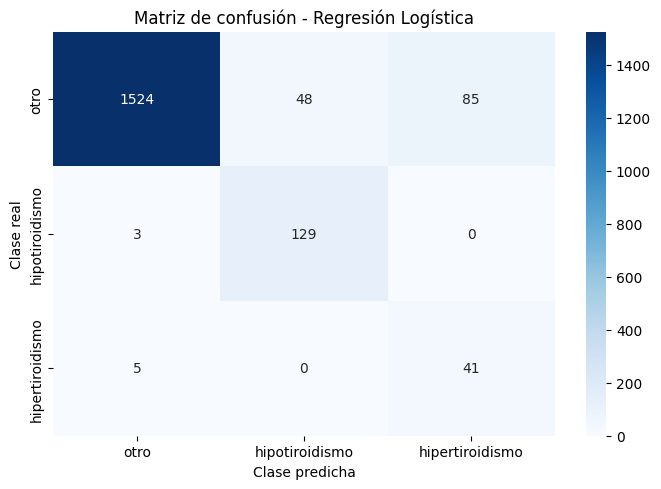

In [9]:
modelo_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
)

modelo_lr.fit(X_train_preprocesado, y_train)
predicciones_lr = modelo_lr.predict(X_test_preprocesado)

metricas_lr = evaluar_modelo(
    "Regresión Logística", y_test, predicciones_lr, "Blues"
)


## KNN

Métricas generales de KNN
-------------------------
Exactitud:            0.9346
Sensibilidad macro:   0.6231
Especificidad macro:  0.8073
Precisión macro:      0.8200
F1-Score macro:       0.6878

Métricas por clase:


,Clase,Sensibilidad,Especificidad,Precisión,F1-Score
0,otro,0.9885,0.4326,0.9419,0.9647
1,hipotiroidismo,0.4242,0.9971,0.9180,0.5803
2,hipertiroidismo,0.4565,0.9922,0.6000,0.5185


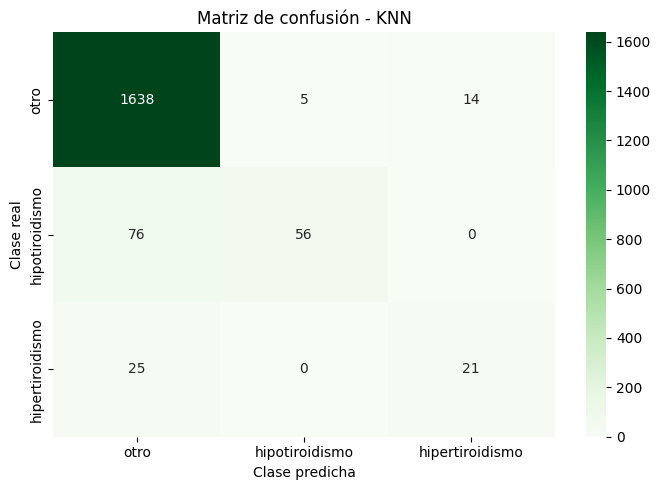

In [15]:
modelo_knn = KNeighborsClassifier(n_neighbors=5)

modelo_knn.fit(X_train_preprocesado, y_train)
predicciones_knn = modelo_knn.predict(X_test_preprocesado)

metricas_knn = evaluar_modelo(
    "KNN", y_test, predicciones_knn, "Greens"
)


## Árbol de decisión

Métricas generales de Árbol de Decisión
---------------------------------------
Exactitud:            0.9760
Sensibilidad macro:   0.8433
Especificidad macro:  0.9496
Precisión macro:      0.8715
F1-Score macro:       0.8564

Métricas por clase:


,Clase,Sensibilidad,Especificidad,Precisión,F1-Score
0,otro,0.9885,0.8596,0.9850,0.9867
1,hipotiroidismo,0.9545,0.9965,0.9545,0.9545
2,hipertiroidismo,0.5870,0.9927,0.6750,0.6279


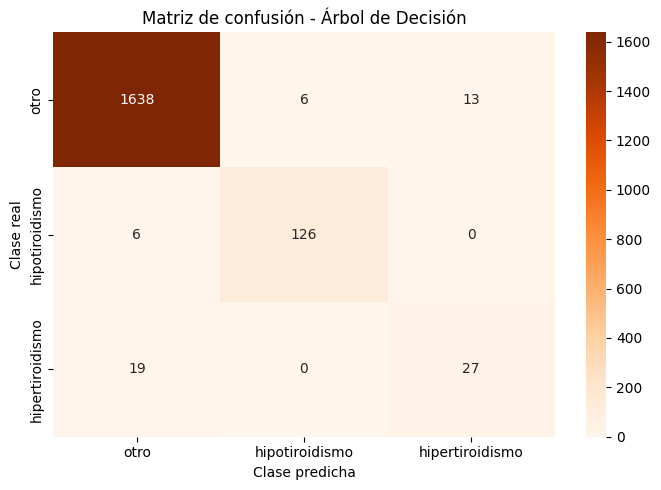

In [16]:
modelo_arbol = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42,
)

modelo_arbol.fit(X_train_preprocesado, y_train)
predicciones_arbol = modelo_arbol.predict(X_test_preprocesado)

metricas_arbol = evaluar_modelo(
    "Árbol de Decisión", y_test, predicciones_arbol, "Oranges"
)


## SVM

Métricas generales de SVM
-------------------------
Exactitud:            0.9330
Sensibilidad macro:   0.9166
Especificidad macro:  0.9580
Precisión macro:      0.6995
F1-Score macro:       0.7746

Métricas por clase:


,Clase,Sensibilidad,Especificidad,Precisión,F1-Score
0,otro,0.9324,0.9382,0.9929,0.9617
1,hipotiroidismo,0.9697,0.9677,0.6995,0.8127
2,hipertiroidismo,0.8478,0.9681,0.4062,0.5493


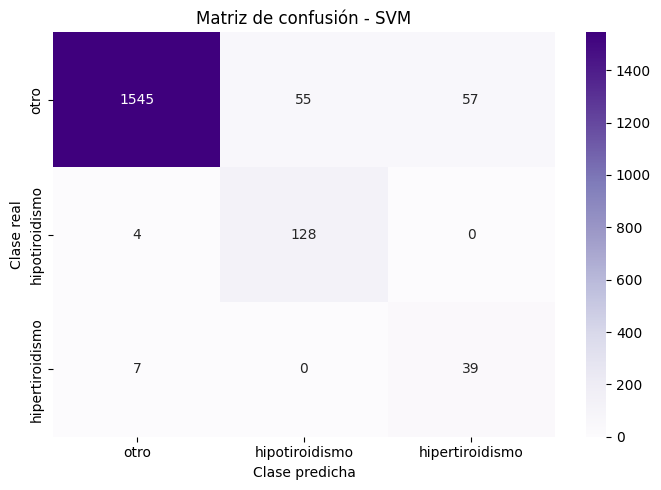

In [17]:
modelo_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
)

modelo_svm.fit(X_train_preprocesado, y_train)
predicciones_svm = modelo_svm.predict(X_test_preprocesado)

metricas_svm = evaluar_modelo(
    "SVM", y_test, predicciones_svm, "Purples"
)


## RF

Métricas generales de Random Forest
-----------------------------------
Exactitud:            0.9798
Sensibilidad macro:   0.8470
Especificidad macro:  0.9560
Precisión macro:      0.8952
F1-Score macro:       0.8670

Métricas por clase:


,Clase,Sensibilidad,Especificidad,Precisión,F1-Score
0,otro,0.9909,0.8764,0.9868,0.9889
1,hipotiroidismo,0.9848,0.9965,0.9559,0.9701
2,hipertiroidismo,0.5652,0.9950,0.7429,0.6420


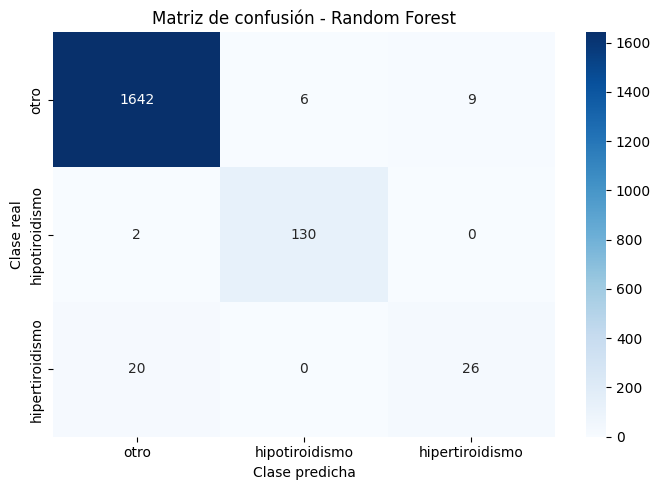

In [13]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

modelo_rf.fit(X_train_preprocesado, y_train)
predicciones_rf = modelo_rf.predict(X_test_preprocesado)

metricas_rf = evaluar_modelo(
    "Random Forest", y_test, predicciones_rf, "Blues"
)


## Comparación de los modelos

In [14]:
comparativa_modelos = pd.DataFrame([
    metricas_lr,
    metricas_knn,
    metricas_arbol,
    metricas_svm,
    metricas_rf,
]).set_index("Modelo")

display(comparativa_modelos.round(4))


,Exactitud,Sensibilidad macro,Especificidad macro,Precisión macro,F1-Score macro
Modelo,,,,,
Regresión Logística,0.9232,0.9294,0.9598,0.6830,0.7558
K-Nearest Neighbors,0.9346,0.6231,0.8073,0.8200,0.6878
Árbol de Decisión,0.9760,0.8433,0.9496,0.8715,0.8564
Support Vector Machine,0.9330,0.9166,0.9580,0.6995,0.7746
Random Forest,0.9798,0.8470,0.9560,0.8952,0.8670
